In [2]:
import os
import re
import logging
import warnings
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    f1_score, 
    recall_score, 
    precision_score,
    roc_curve,
    auc
)
from sklearn.impute import SimpleImputer

# Suppress Optuna's default console output to handle it via our custom logger
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')


def setup_logger(out_dir: Path, log_filename: str = "rf_training.log") -> logging.Logger:
    """Configures a dual-stream logger to write to both console and a log file."""
    logger = logging.getLogger("RF_Optimizer")
    logger.setLevel(logging.INFO)
    
    if logger.hasHandlers():
        logger.handlers.clear()
        
    formatter = logging.Formatter('%(asctime)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
    
    fh = logging.FileHandler(out_dir / log_filename)
    fh.setFormatter(formatter)
    logger.addHandler(fh)
    
    ch = logging.StreamHandler()
    ch.setFormatter(formatter)
    logger.addHandler(ch)
    
    return logger


def load_and_preprocess_data(
    data_path: Path, 
    label_map: Dict[str, int],
    start_date: Optional[str],
    end_date: Optional[str],
    logger: logging.Logger
) -> Tuple[np.ndarray, np.ndarray]:
    """Loads dataset, extracts/filters temporal features by date, and maps labels."""
    logger.info(f"Loading dataset from: {data_path}")
    
    if data_path.suffix == '.parquet':
        df = pd.read_parquet(data_path)
    else:
        df = pd.read_csv(data_path)
        
    meta_cols = ['AOI', 'Cluster_ID', 'Cluster_Label', 'Feature_Type', 'Pixel_ID', 'Confidence_Score']
    all_feature_cols = [c for c in df.columns if c not in meta_cols]
    
    # Filter features based on date range if provided
    if start_date and end_date:
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)
        valid_cols = []
        
        for col in all_feature_cols:
            # Extract standard date patterns (YYYY-MM-DD, YYYY/MM/DD, YYYYMMDD) from column strings
            match = re.search(r'\d{4}[-/]\d{2}[-/]\d{2}|\d{8}', str(col))
            try:
                if match:
                    col_dt = pd.to_datetime(match.group())
                else:
                    # Fallback: attempt direct parsing if no regex match
                    col_dt = pd.to_datetime(col)
                
                if start_dt <= col_dt <= end_dt:
                    valid_cols.append(col)
            except (ValueError, TypeError):
                # Column doesn't contain a parseable date, skip it
                pass
                
        feature_cols = valid_cols
        logger.info(f"Date filter applied ({start_date} to {end_date}). Selected {len(feature_cols)} temporal features.")
        if not feature_cols:
            raise ValueError(f"No temporal feature columns matched the date range {start_date} to {end_date}.")
    else:
        feature_cols = all_feature_cols
        
    X = df[feature_cols].values
    
    if 'Cluster_Label' not in df.columns:
        raise KeyError("'Cluster_Label' column is missing from the dataset.")
        
    y = df['Cluster_Label'].map(label_map)
    
    if y.isnull().any():
        unmapped = df[y.isnull()]['Cluster_Label'].unique()
        raise ValueError(f"Found unmapped labels in dataset: {unmapped}. Update label_map.")
        
    y = y.values.astype(int)
    
    if np.isnan(X).any():
        logger.info("Imputing NaN values in features using mean strategy...")
        imputer = SimpleImputer(strategy='mean')
        X = imputer.fit_transform(X)
        
    logger.info(f"Data matrix shape: {X.shape}. Model expects exactly {len(feature_cols)} sequential features.")
    return X, y


def execute_rf_pipeline(
    input_path: str,
    output_dir: str,
    label_mapping: Dict[str, int],
    target_pos_label: int,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    n_trials: int = 30,
    n_folds: int = 5,
    test_size: float = 0.2
) -> None:
    """Executes the full ML pipeline with explicit I/O paths and dynamic temporal filtering."""
    
    data_path = Path(input_path)
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    logger = setup_logger(out_dir)
    logger.info("=== Initializing GeoAI Random Forest Pipeline ===")
    
    # 1. Data Prep
    X, y = load_and_preprocess_data(data_path, label_mapping, start_date, end_date, logger)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    logger.info(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")

    # 2. Bayesian Optimization via Optuna
    logger.info(f"\n--- Starting Bayesian Optimization ({n_trials} Trials, {n_folds}-Fold CV) ---")
    
    def objective(trial: optuna.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        }
        
        rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        
        scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
        mean_acc = scores.mean()
        
        logger.info(f"Iteration {trial.number + 1}/{n_trials} | Acc: {mean_acc:.4f} | Params: {params}")
        return mean_acc

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    best_params = study.best_params
    logger.info(f"\nOptimization Complete. Highest CV Accuracy: {study.best_value:.4f}")
    logger.info(f"Best Parameters: {best_params}")

    # 3. Final Model Training & Export
    logger.info("\n--- Training Final Date-Agnostic Model on full Training Set ---")
    best_rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    best_rf.fit(X_train, y_train)
    
    model_path = out_dir / "best_rf_classifier.joblib"
    joblib.dump(best_rf, model_path)
    logger.info(f"Model saved to: {model_path}")

    # 4. Evaluation on Unseen Test Set
    logger.info("\n--- Evaluating on Test Set ---")
    y_pred = best_rf.predict(X_test)
    
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, pos_label=target_pos_label)
    test_recall = recall_score(y_test, y_pred, pos_label=target_pos_label)
    test_prec = precision_score(y_test, y_pred, pos_label=target_pos_label)
    conf_mat = confusion_matrix(y_test, y_pred)

    logger.info(f"Test Accuracy: {test_acc:.4f}")
    logger.info(f"Precision: {test_prec:.4f} | Recall: {test_recall:.4f} | F1-Score: {test_f1:.4f}")
    logger.info("\nConfusion Matrix:")
    logger.info(f"\n{conf_mat}")
    logger.info("\nClassification Report:")
    logger.info(f"\n{classification_report(y_test, y_pred)}")

    # 5. Visualizations
    logger.info("\n--- Generating Plots ---")
    sns.set_theme(style="whitegrid")
    
    # Plot A: Confusion Matrix
    plt.figure(figsize=(7, 5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_mapping.values(), yticklabels=label_mapping.values())
    plt.title('Random Forest Confusion Matrix')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig(out_dir / "confusion_matrix.png", dpi=300)
    plt.show() 
    plt.close()

    # Plot B: Metrics Bar Chart
    plt.figure(figsize=(7, 5))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [test_acc, test_prec, test_recall, test_f1]
    
    ax = sns.barplot(x=metrics, y=values, hue=metrics, palette='viridis', legend=False)
    plt.title(f'Test Metrics (Target Class: {target_pos_label})')
    plt.ylim(0, 1.1)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(out_dir / "performance_metrics.png", dpi=300)
    plt.show() 
    plt.close()

    # Plot C: Receiver Operating Characteristic (ROC) Curve
    plt.figure(figsize=(7, 5))
    # Isolate the predicted probabilities for the target positive label
    pos_idx = np.where(best_rf.classes_ == target_pos_label)[0][0]
    y_pred_proba = best_rf.predict_proba(X_test)[:, pos_idx]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=target_pos_label)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_dir / "roc_curve.png", dpi=300)
    plt.show() 
    plt.close()

    logger.info(f"All artifacts saved successfully in: {out_dir}")



2026-09-04 11:29:30 - === Initializing GeoAI Random Forest Pipeline ===
2026-09-04 11:29:30 - Loading dataset from: /home/jovyan/FAO/cotton/training_data_parquet/cotton_2025_training_data_v2.csv
2026-09-04 11:29:30 - Date filter applied (2025-04-01 to 2025-12-31). Selected 35 temporal features.
2026-09-04 11:29:30 - Data matrix shape: (22243, 35). Model expects exactly 35 sequential features.
2026-09-04 11:29:30 - Train set: 17794 samples | Test set: 4449 samples
2026-09-04 11:29:30 - 
--- Starting Bayesian Optimization (35 Trials, 3-Fold CV) ---
2026-09-04 11:29:38 - Iteration 1/35 | Acc: 0.9110 | Params: {'n_estimators': 450, 'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'log2'}
2026-09-04 11:29:46 - Iteration 2/35 | Acc: 0.9238 | Params: {'n_estimators': 400, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
2026-09-04 11:29:51 - Iteration 3/35 | Acc: 0.9157 | Params: {'n_estimators': 250, 'max_depth': 13, 'min_

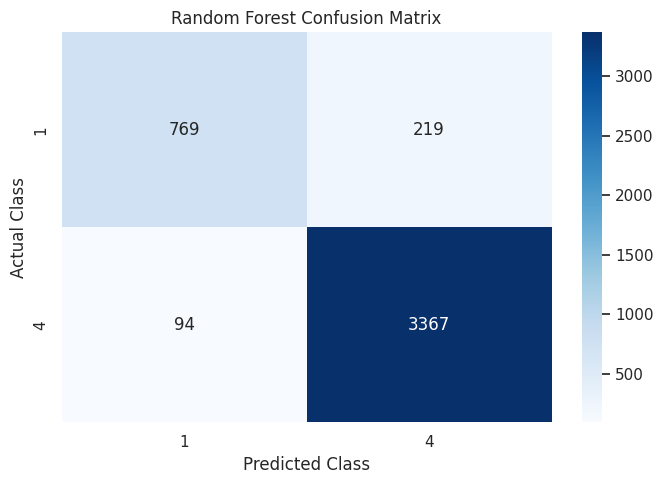

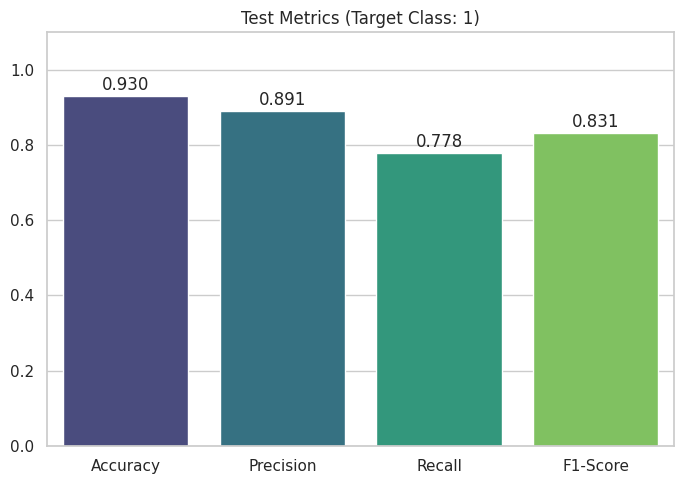

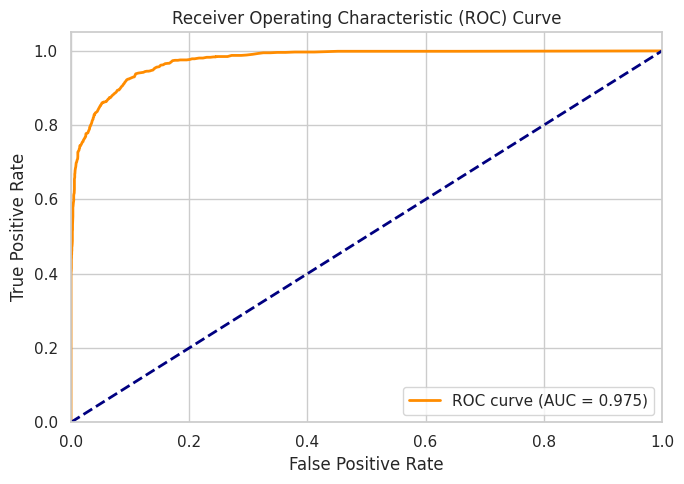

2026-09-04 11:32:29 - All artifacts saved successfully in: /home/jovyan/FAO/cotton/timeseries_model/model_v1


In [3]:

if __name__ == "__main__":
    
    # I/O Parameters
    INPUT_FILE = "/home/jovyan/FAO/cotton/training_data_parquet/cotton_2025_training_data_v2.csv"
    OUTPUT_DIR = "/home/jovyan/FAO/cotton/timeseries_model/model_v1"
    
    # Temporal Parameters (Set to None to use all available columns)
    START_DATE = "2025-04-01"
    END_DATE = "2025-12-31"
    
    # Model Targets
    LABELS = {
        "cotton": 1,
        "non-cotton": 4
    }
    TARGET_CROP = 1 
    
    execute_rf_pipeline(
        input_path=INPUT_FILE,
        output_dir=OUTPUT_DIR,
        label_mapping=LABELS,
        target_pos_label=TARGET_CROP,
        start_date=START_DATE,
        end_date=END_DATE,
        n_trials=35,      
        n_folds=3,        
        test_size=0.20   
    )